In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("data.csv")
data.head()

,Name,Age,Views,Likes,Category
0,Video1,18,1000,120,Gaming
1,Video2,21,5000,600,Sports
2,Video3,20,2500,300,Gaming
3,Video4,25,12000,1400,Tech
4,Video5,22,7000,800,Sports


# Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the dataset by exploring, cleaning, visualizing, and drawing conclusions.

In [3]:
print("Rows and Columns:")
print(data.shape)

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nSummary Statistics:")
print(data.describe())

print("\nCategory Counts:")
print(data["Category"].value_counts())

Rows and Columns:
(8, 5)

Data Types:
Name        object
Age          int64
Views        int64
Likes        int64
Category    object
dtype: object

Missing Values:
Name        0
Age         0
Views       0
Likes       0
Category    0
dtype: int64

Summary Statistics:
            Age         Views        Likes
count   8.00000      8.000000     8.000000
mean   21.50000   5500.000000   643.750000
std     2.44949   3826.598639   438.176008
min    18.00000   1000.000000   120.000000
25%    19.75000   2250.000000   270.000000
50%    21.50000   5500.000000   675.000000
75%    23.25000   7500.000000   850.000000
max    25.00000  12000.000000  1400.000000

Category Counts:
Category
Gaming    3
Sports    3
Tech      2
Name: count, dtype: int64


## Data Cleaning

In [4]:
data = data.drop_duplicates()

data["Name"] = data["Name"].str.strip()
data["Category"] = data["Category"].str.strip()
data["Category"] = data["Category"].str.title()

data["Age"] = pd.to_numeric(data["Age"])
data["Views"] = pd.to_numeric(data["Views"])
data["Likes"] = pd.to_numeric(data["Likes"])

data.head()

,Name,Age,Views,Likes,Category
0,Video1,18,1000,120,Gaming
1,Video2,21,5000,600,Sports
2,Video3,20,2500,300,Gaming
3,Video4,25,12000,1400,Tech
4,Video5,22,7000,800,Sports


## Feature Engineering

In [5]:
data["EngagementRate"] = data["Likes"] / data["Views"]

data.head()

,Name,Age,Views,Likes,Category,EngagementRate
0,Video1,18,1000,120,Gaming,0.120000
1,Video2,21,5000,600,Sports,0.120000
2,Video3,20,2500,300,Gaming,0.120000
3,Video4,25,12000,1400,Tech,0.116667
4,Video5,22,7000,800,Sports,0.114286


## Visualizations

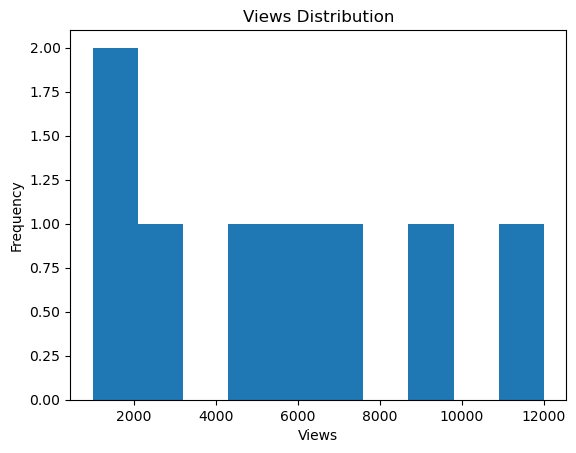

In [6]:
plt.hist(data["Views"])
plt.title("Views Distribution")
plt.xlabel("Views")
plt.ylabel("Frequency")
plt.show()

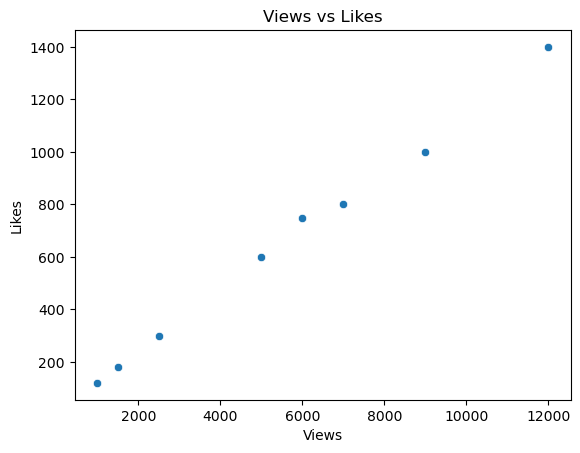

In [7]:
sns.scatterplot(x="Views", y="Likes", data=data)
plt.title("Views vs Likes")
plt.show()

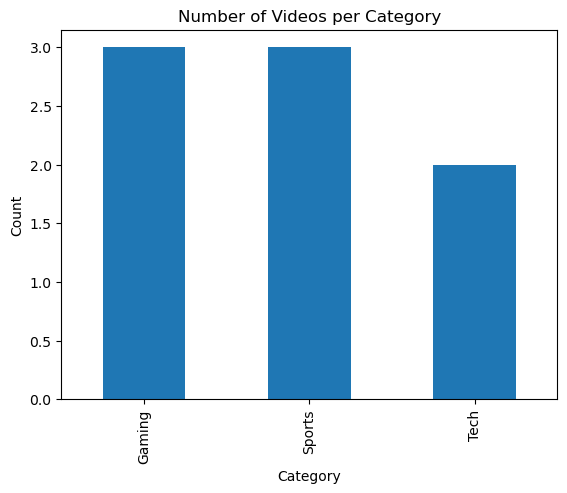

In [8]:
data["Category"].value_counts().plot(kind="bar")
plt.title("Number of Videos per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

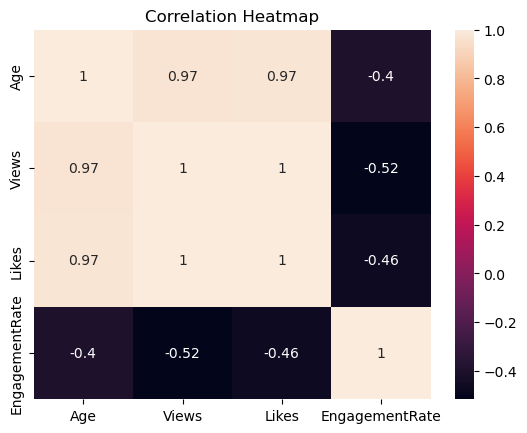

In [9]:
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Conclusions

In [10]:
print("The dataset was cleaned by removing duplicates, fixing text spacing, and checking numeric columns.")
print("The most common category is:", data["Category"].value_counts().idxmax())
print("The video with the most views is:", data.loc[data["Views"].idxmax(), "Name"])
print("Views and likes appear to have a positive relationship.")

The dataset was cleaned by removing duplicates, fixing text spacing, and checking numeric columns.
The most common category is: Gaming
The video with the most views is: Video4
Views and likes appear to have a positive relationship.
